In [9]:
%pip install -U "setuptools<81" tropycal
%pip install shapely

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 13.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import tropycal.tracks as tracks
import datetime

# 1. Tải dữ liệu bão khu vực Tây Bắc Thái Bình Dương (WP) từ IBTrACS
# Lưu ý: Lần đầu chạy sẽ hơi chậm vì nó tải dữ liệu lịch sử về máy
print("Đang tải dữ liệu bão từ IBTrACS... Vui lòng đợi.")
ibtracs = tracks.TrackDataset(basin='west_pacific', source='ibtracs')

# 2. Lấy danh sách tất cả các ID bão trong khu vực WP
all_storm_ids = ibtracs.get_storm_ids()

# 3. Lấy 3 ID cuối cùng (mới nhất)
latest_3_ids = all_storm_ids[-3:]

print("-" * 30)
print(f"3 CƠN BÃO MỚI NHẤT TRONG KHU VỰC WP:")
print("-" * 30)

# 4. Duyệt qua từng ID bão để lấy thông tin chi tiết
for storm_id in latest_3_ids:
    storm = ibtracs.get_storm(storm_id)
    
    # Lấy thông tin cơ bản
    name = storm.name
    start_time = storm.date[0].strftime('%d/%m/%Y')
    end_time = storm.date[-1].strftime('%d/%m/%Y')
    max_wind = max(storm.vmax) # Sức gió cực đại (knots)
    min_mslp = min(storm.mslp) # Áp suất thấp nhất (hPa)

    print(f"Tên bão: {name} ({storm_id})")
    print(f"  - Thời gian: {start_time} đến {end_time}")
    print(f"  - Sức gió mạnh nhất: {max_wind} knots")
    print(f"  - Áp suất thấp nhất: {min_mslp} hPa")
    print("-" * 20)

# 5. (Tùy chọn) Vẽ quỹ đạo của cơn bão mới nhất
latest_storm = ibtracs.get_storm(latest_3_ids[-1])
latest_storm.plot()

In [11]:
%pip install cartopy

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 6.7 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/11.0 MB 9.7 MB/s eta 0:00:01
   -------------- ------------------------- 3.9/11.0 MB 7.8 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.0 MB 8.9 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.0 MB 9.9 MB/s eta 0:00:01
   ----------------------------------- ---- 9.7/11.0 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 8.7 MB/s  0:00:01
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ----------- ---------------------------- 1.8/6.3 MB 9.1 MB/s eta 0:00:01
   --------------------- ------------------ 3.4/6.3 MB 8.4 MB/s eta 0:00:01
   ------------------------------ --------- 4.7/6.3 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 7.7 MB/s  0:00:00

   -------------------

In [12]:
from __future__ import annotations

import os
from typing import Any, Iterable

# Workaround for tropycal package builds that rely on git metadata at import time.
os.environ.setdefault("SETUPTOOLS_SCM_PRETEND_VERSION_FOR_TROPYCAL", "1.4")

from tropycal import realtime


def print_section(title: str) -> None:
    print(f"\n{'=' * 90}")
    print(title)
    print(f"{'=' * 90}")


def preview_sequence(values: Any, n: int = 5) -> list[Any]:
    """Return a safe first-N preview for list-like objects."""
    if values is None:
        return []

    # Handle standard list-like structures.
    if isinstance(values, (list, tuple)):
        return list(values[:n])

    # Handle numpy/pandas-like sequences that support slicing.
    try:
        return list(values[:n])
    except Exception:  # noqa: BLE001
        pass

    # Handle generic iterables.
    if isinstance(values, Iterable) and not isinstance(values, (str, bytes, dict)):
        result: list[Any] = []
        for idx, item in enumerate(values):
            if idx >= n:
                break
            result.append(item)
        return result

    return []


def get_storm_dict(storm: Any) -> dict[str, Any]:
    """Safely get storm.dict if available and dict-like."""
    data = getattr(storm, "dict", None)
    return data if isinstance(data, dict) else {}


def print_data_preview(storm_data: dict[str, Any], key: str, n: int = 5) -> None:
    values = storm_data.get(key)
    preview = preview_sequence(values, n=n)
    print(f"- {key:<6}: len={len(values) if hasattr(values, '__len__') else 'N/A'} | first {n}: {preview}")


def print_forecast_preview(storm_data: dict[str, Any], n: int = 5) -> None:
    forecast = storm_data.get("forecast")
    if not isinstance(forecast, dict) or len(forecast) == 0:
        print("Forecast data: not available")
        return

    print("Forecast data: available")
    print(f"- forecast keys: {list(forecast.keys())}")

    fhr = forecast.get("fhr")
    fhr_preview = preview_sequence(fhr, n=n)
    print(f"- fhr         : len={len(fhr) if hasattr(fhr, '__len__') else 'N/A'} | first {n}: {fhr_preview}")

    flat = forecast.get("lat")
    flon = forecast.get("lon")
    flat_preview = preview_sequence(flat, n=n)
    flon_preview = preview_sequence(flon, n=n)

    point_pairs = list(zip(flat_preview, flon_preview))
    print(f"- forecast lat: len={len(flat) if hasattr(flat, '__len__') else 'N/A'} | first {n}: {flat_preview}")
    print(f"- forecast lon: len={len(flon) if hasattr(flon, '__len__') else 'N/A'} | first {n}: {flon_preview}")
    print(f"- lat/lon pairs first {n}: {point_pairs}")


def main() -> None:
    print_section("TROPYCAL STORM STRUCTURE EXPLORER")
    print("Initializing realtime dataset...")

    rt = realtime.Realtime()
    storms = getattr(rt, "storms", {})

    if not isinstance(storms, dict) or len(storms) == 0:
        print("No active storms found.")
        return

    print(f"Active storms found: {len(storms)}")

    for idx, (storm_id, storm) in enumerate(storms.items(), start=1):
        storm_name = getattr(storm, "name", "UNKNOWN")

        print_section(f"STORM {idx}: {storm_id} - {storm_name}")

        print("1) Basic Info")
        print(f"- storm_id: {storm_id}")
        print(f"- name    : {storm_name}")

        print("\n2) Available Attributes (dir)")
        attrs = dir(storm)
        print(f"- total attributes: {len(attrs)}")
        print(attrs)

        print("\n3) storm.dict keys")
        storm_data = get_storm_dict(storm)
        if not storm_data:
            print("- storm.dict missing or empty")
        else:
            print(f"- total keys: {len(storm_data.keys())}")
            print(f"- keys: {list(storm_data.keys())}")

        print("\n4) Core Series Preview (first 5 entries)")
        for key in ["time", "lat", "lon", "vmax", "mslp"]:
            print_data_preview(storm_data, key, n=5)

        print("\n5) Forecast Preview")
        print_forecast_preview(storm_data, n=5)

    print_section("DONE")
    print("Storm structure exploration complete.")


if __name__ == "__main__":
    main()



TROPYCAL STORM STRUCTURE EXPLORER
Initializing realtime dataset...
--> Starting to read in current storm data
--> Completed reading in current storm data (1.71 seconds)
No active storms found.


In [13]:
from tropycal import tracks

In [2]:
from tropycal import tracks

# Load toàn bộ dataset Bắc Đại Tây Dương
basin = tracks.TrackDataset(basin='north_atlantic')

# Lấy 1 cơn bão nổi tiếng
storm = basin.get_storm(('irma', 2017))

print(storm)
print ("hello")
print(storm.dict.keys())

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (1.55 seconds)
<tropycal.tracks.Storm>
Storm Summary:
    Maximum Wind:      155 knots
    Minimum Pressure:  914 hPa
    Start Time:        0000 UTC 30 August 2017
    End Time:          0000 UTC 12 September 2017

Variables:
    time        (datetime) [2017-08-30 00:00:00 .... 2017-09-13 12:00:00]
    extra_obs   (int64) [0 .... 0]
    special     (str) [ .... ]
    type        (str) [TD .... LO]
    lat         (float64) [16.1 .... 36.8]
    lon         (float64) [-26.9 .... -90.1]
    vmax        (int64) [30 .... 15]
    mslp        (int64) [1008 .... 1005]
    wmo_basin   (str) [north_atlantic .... north_atlantic]

More Information:
    id:              AL112017
    operational_id:  AL112017
    name:            IRMA
    year:            2017
    season:          2017
    basin:           north_atlantic
    source_info:     NHC Hurricane Database
    source:          hurdat
    ace:             64.9
    rea

In [15]:
data = storm.dict

times = data['time']
lats = data['lat']
lons = data['lon']
vmax = data['vmax']
mslp = data['mslp']
types = data['type']

for i in range(len(times)):
    print(f"Time: {times[i]}")
    print(f"  Location : ({lats[i]}, {lons[i]})")
    print(f"  Wind     : {vmax[i]} kt")
    print(f"  Pressure : {mslp[i]} mb")
    print(f"  Type     : {types[i]}")
    print("-" * 50)

Time: 2017-08-30 00:00:00
  Location : (16.1, -26.9)
  Wind     : 30 kt
  Pressure : 1008 mb
  Type     : TD
--------------------------------------------------
Time: 2017-08-30 06:00:00
  Location : (16.2, -28.3)
  Wind     : 35 kt
  Pressure : 1007 mb
  Type     : TS
--------------------------------------------------
Time: 2017-08-30 12:00:00
  Location : (16.3, -29.7)
  Wind     : 45 kt
  Pressure : 1006 mb
  Type     : TS
--------------------------------------------------
Time: 2017-08-30 18:00:00
  Location : (16.3, -30.8)
  Wind     : 50 kt
  Pressure : 1004 mb
  Type     : TS
--------------------------------------------------
Time: 2017-08-31 00:00:00
  Location : (16.3, -31.7)
  Wind     : 55 kt
  Pressure : 999 mb
  Type     : TS
--------------------------------------------------
Time: 2017-08-31 06:00:00
  Location : (16.4, -32.5)
  Wind     : 65 kt
  Pressure : 994 mb
  Type     : HU
--------------------------------------------------
Time: 2017-08-31 12:00:00
  Location : (16

## Demo ảnh trạng thái bão Irma (2017) từ thư mục images
Cell này dùng các icon trong `images/` để trực quan hóa trạng thái từng điểm track của cơn bão `storm = basin.get_storm(('irma', 2017))`.

In [23]:
from pathlib import Path

import pandas as pd
import folium
from IPython.display import display

# Đường dẫn thư mục ảnh định nghĩa icon trạng thái bão
image_dir = Path("images")
available_icons = sorted([p.name for p in image_dir.glob("*.png")])

# Định nghĩa icon từ chính thư mục images (chuẩn hóa theo naming hiện có)
_icon_meta_by_stem = {
    "LOW": {"label": "Low", "active": False},
    "TD": {"label": "Tropical Depression", "active": True},
    "TS": {"label": "Tropical Storm", "active": True},
    "TY": {"label": "Hurricane/Typhoon", "active": True},
    "TSSH": {"label": "Tropical Storm (South Hemisphere)", "active": True},
    "TYSH": {"label": "Typhoon (South Hemisphere)", "active": True},
    "TDgray": {"label": "Post/Weak Depression", "active": False},
    "TSgray": {"label": "Post/Weak Storm", "active": False},
    "TYgray": {"label": "Post/Weak Hurricane", "active": False},
    "TSgraySH": {"label": "Post/Weak Storm (SH)", "active": False},
    "TYgraySH": {"label": "Post/Weak Typhoon (SH)", "active": False},
}

ICON_DEFINITIONS = {}
for icon_name in available_icons:
    stem = Path(icon_name).stem
    if stem in _icon_meta_by_stem:
        ICON_DEFINITIONS[stem] = {
            "file": icon_name,
            "label": _icon_meta_by_stem[stem]["label"],
            "active": _icon_meta_by_stem[stem]["active"],
        }

def infer_storm_icon_stem(storm_type: str, lat: float | None = None) -> str:
    """Map loại bão trong Tropycal sang stem của icon trong images/."""
    t = (storm_type or "").upper()
    south_hemi = (lat is not None) and (lat < 0)

    if t in {"TD"}:
        return "TD"
    if t in {"TS", "SS"}:
        return "TSSH" if south_hemi and "TSSH" in ICON_DEFINITIONS else "TS"
    if t in {"HU", "TY", "ST"}:
        return "TYSH" if south_hemi and "TYSH" in ICON_DEFINITIONS else "TY"
    if t in {"LO"}:
        return "LOW"
    if t in {"EX", "DB", "WV", "SD", "ET"}:
        if south_hemi and "TSgraySH" in ICON_DEFINITIONS:
            return "TSgraySH"
        return "TDgray"

    # fallback mặc định nếu type lạ
    return "TDgray" if "TDgray" in ICON_DEFINITIONS else "TD"

def icon_file_from_type(storm_type: str, lat: float | None = None) -> str:
    stem = infer_storm_icon_stem(storm_type, lat=lat)
    if stem in ICON_DEFINITIONS:
        return ICON_DEFINITIONS[stem]["file"]
    return next(iter(ICON_DEFINITIONS.values()))["file"]

# Chuyển dữ liệu track của Irma thành DataFrame để dễ demo
track_df = pd.DataFrame(
    {
        "time": storm.dict.get("time", []),
        "lat": storm.dict.get("lat", []),
        "lon": storm.dict.get("lon", []),
        "vmax": storm.dict.get("vmax", []),
        "mslp": storm.dict.get("mslp", []),
        "type": storm.dict.get("type", []),
    }
)

track_df["icon_file"] = track_df.apply(
    lambda r: icon_file_from_type(str(r["type"]), lat=float(r["lat"]) if pd.notna(r["lat"]) else None),
    axis=1,
)

track_df["icon_label"] = track_df.apply(
    lambda r: ICON_DEFINITIONS[infer_storm_icon_stem(str(r["type"]), lat=float(r["lat"]) if pd.notna(r["lat"]) else None)]["label"],
    axis=1,
)

print(f"So diem track cua Irma 2017: {len(track_df)}")
display(track_df.head(15))

print("\nDanh sach icon co san:", available_icons)
print("\nDanh sach dinh nghia icon da load:")
for stem, meta in ICON_DEFINITIONS.items():
    print(f"- {stem:8} -> {meta['file']:14} | {meta['label']}")

So diem track cua Irma 2017: 66


,time,lat,lon,vmax,mslp,type,icon_file,icon_label
0,2017-08-30 00:00:00,16.1,-26.9,30,1008,TD,TD.png,Tropical Depression
1,2017-08-30 06:00:00,16.2,-28.3,35,1007,TS,TS.png,Tropical Storm
2,2017-08-30 12:00:00,16.3,-29.7,45,1006,TS,TS.png,Tropical Storm
3,2017-08-30 18:00:00,16.3,-30.8,50,1004,TS,TS.png,Tropical Storm
4,2017-08-31 00:00:00,16.3,-31.7,55,999,TS,TS.png,Tropical Storm
5,2017-08-31 06:00:00,16.4,-32.5,65,994,HU,TY.png,Hurricane/Typhoon
6,2017-08-31 12:00:00,16.7,-33.4,80,983,HU,TY.png,Hurricane/Typhoon
7,2017-08-31 18:00:00,17.1,-34.2,95,970,HU,TY.png,Hurricane/Typhoon
8,2017-09-01 00:00:00,17.5,-35.1,100,967,HU,TY.png,Hurricane/Typhoon
9,2017-09-01 06:00:00,17.9,-36.1,100,967,HU,TY.png,Hurricane/Typhoon



Danh sach icon co san: ['JTWCtranslogo.png', 'LOW.png', 'TD.png', 'TDgray.png', 'TS.png', 'TSSH.png', 'TSgray.png', 'TSgraySH.png', 'TY.png', 'TYSH.png', 'TYgray.png', 'TYgraySH.png']

Danh sach dinh nghia icon da load:
- LOW      -> LOW.png        | Low
- TD       -> TD.png         | Tropical Depression
- TDgray   -> TDgray.png     | Post/Weak Depression
- TS       -> TS.png         | Tropical Storm
- TSSH     -> TSSH.png       | Tropical Storm (South Hemisphere)
- TSgray   -> TSgray.png     | Post/Weak Storm
- TSgraySH -> TSgraySH.png   | Post/Weak Storm (SH)
- TY       -> TY.png         | Hurricane/Typhoon
- TYSH     -> TYSH.png       | Typhoon (South Hemisphere)
- TYgray   -> TYgray.png     | Post/Weak Hurricane
- TYgraySH -> TYgraySH.png   | Post/Weak Typhoon (SH)


In [20]:
# Tạo bản đồ demo: track Irma + icon trạng thái theo từng điểm
valid_df = track_df.dropna(subset=["lat", "lon"]).copy()

if valid_df.empty:
    print("Khong co du lieu toa do de ve ban do.")
else:
    center_lat = float(valid_df["lat"].mean())
    center_lon = float(valid_df["lon"].mean())

    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles="CartoDB positron")

    # Vẽ track line
    folium.PolyLine(
        locations=valid_df[["lat", "lon"]].values.tolist(),
        color="#1f77b4",
        weight=3,
        opacity=0.8,
        tooltip="Irma 2017 track",
    ).add_to(m)

    # Vẽ marker icon tại mỗi điểm
    for _, row in valid_df.iterrows():
        icon_path = image_dir / row["icon_file"]
        popup_text = (
            f"Time: {row['time']}<br>"
            f"Type: {row['type']}<br>"
            f"Wind: {row['vmax']} kt<br>"
            f"Pressure: {row['mslp']} mb"
        )

        custom_icon = folium.CustomIcon(
            icon_image=str(icon_path),
            icon_size=(26, 26),
            icon_anchor=(13, 13),
        )

        folium.Marker(
            location=[float(row["lat"]), float(row["lon"])],
            icon=custom_icon,
            popup=folium.Popup(popup_text, max_width=300),
        ).add_to(m)

    # Legend đơn giản để giải thích icon
    legend_html = """
    <div style="
        position: fixed; 
        bottom: 20px; left: 20px; width: 230px; z-index: 9999; 
        background: white; border: 1px solid #999; border-radius: 8px;
        padding: 10px; font-size: 13px; box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    ">
      <b>Irma 2017 - Icon Legend</b><br>
      <img src="images/TD.png" width="16"> TD<br>
      <img src="images/TS.png" width="16"> TS / SS<br>
      <img src="images/TY.png" width="16"> HU / TY / ST<br>
      <img src="images/LOW.png" width="16"> LO<br>
      <img src="images/TDgray.png" width="16"> EX / Other
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    output_html = "irma_2017_icon_demo_map.html"
    m.save(output_html)
    print(f"Da tao demo map: {output_html}")
    m

Da tao demo map: irma_2017_icon_demo_map.html


## Demo cone + forecast giả cho Irma tại thời điểm 2017-09-02 00:00
Mục tiêu: mô phỏng một cơn bão đang hoạt động tại mốc `2017-09-02 00:00:00`, dùng dữ liệu quá khứ làm **track đã quan sát**, và tạo **forecast giả 5 ngày** theo đúng cấu trúc forecast để test pipeline.

In [24]:
import math
from datetime import timedelta

import numpy as np
import pandas as pd
import folium
from IPython.display import display

# 1) Thiết lập mốc thời gian mô phỏng
track_start = pd.Timestamp("2017-08-30 00:00:00")
track_cutoff = pd.Timestamp("2017-09-02 00:00:00")

# Forecast 5 ngày theo yêu cầu
forecast_hours = [0, 12, 24, 36, 48, 72, 96, 120]
cone_error_km = [0, 50, 80, 120, 150, 220, 300, 350]

# 2) Chuẩn hóa dữ liệu track Irma
full_df = pd.DataFrame(
    {
        "time": pd.to_datetime(storm.dict.get("time", [])),
        "lat": storm.dict.get("lat", []),
        "lon": storm.dict.get("lon", []),
        "vmax": storm.dict.get("vmax", []),
        "mslp": storm.dict.get("mslp", []),
        "type": storm.dict.get("type", []),
    }
).dropna(subset=["time", "lat", "lon"]).sort_values("time")

# Track quan sát: từ 30/8 đến 2/9
obs_df = full_df[(full_df["time"] >= track_start) & (full_df["time"] <= track_cutoff)].copy()

# 3) Tạo forecast giả bằng nội suy theo dữ liệu thật sau cutoff
forecast_times = [track_cutoff + pd.Timedelta(hours=h) for h in forecast_hours]
interp_source = full_df.set_index("time")[["lat", "lon", "vmax"]].sort_index()

all_times = interp_source.index.union(pd.DatetimeIndex(forecast_times))
interp_all = interp_source.reindex(all_times).interpolate(method="time").loc[forecast_times]

forecast_df = pd.DataFrame(
    {
        "time": forecast_times,
        "fhr": forecast_hours,
        "lat": interp_all["lat"].to_list(),
        "lon": interp_all["lon"].to_list(),
        "vmax": interp_all["vmax"].to_list(),
        "cone_error_km": cone_error_km,
    }
)

def classify_type_from_vmax(vmax: float) -> str:
    if pd.isna(vmax):
        return "TD"
    if vmax < 34:
        return "TD"
    if vmax < 64:
        return "TS"
    return "HU"

forecast_df["type"] = forecast_df["vmax"].map(classify_type_from_vmax)
forecast_df["icon_file"] = forecast_df.apply(
    lambda r: icon_file_from_type(str(r["type"]), lat=float(r["lat"])),
    axis=1,
)

forecast = {
    "fhr": forecast_df["fhr"].to_list(),
    "lat": forecast_df["lat"].to_list(),
    "lon": forecast_df["lon"].to_list(),
}

print("=== Forecast giả đúng cấu trúc cần test ===")
print(forecast)

print("\n=== Track (quan sát) ===")
print(f"From: {obs_df['time'].min()}  To: {obs_df['time'].max()}  | points={len(obs_df)}")

print("\n=== Forecast window ===")
print(f"From: {forecast_df['time'].min()}  To: {forecast_df['time'].max()}  | points={len(forecast_df)}")

display(forecast_df)

=== Forecast giả đúng cấu trúc cần test ===
{'fhr': [0, 12, 24, 36, 48, 72, 96, 120], 'lat': [19.1, 18.9, 18.5, 17.9, 17.3, 16.6, 17.3, 19.2], 'lon': [-39.7, -42.6, -45.5, -47.9, -50.4, -55.1, -60.6, -66.2]}

=== Track (quan sát) ===
From: 2017-08-30 00:00:00  To: 2017-09-02 00:00:00  | points=13

=== Forecast window ===
From: 2017-09-02 00:00:00  To: 2017-09-07 00:00:00  | points=8


,time,fhr,lat,lon,vmax,cone_error_km,type,icon_file
0,2017-09-02 00:00:00,0,19.1,-39.7,100,0,HU,TY.png
1,2017-09-02 12:00:00,12,18.9,-42.6,95,50,HU,TY.png
2,2017-09-03 00:00:00,24,18.5,-45.5,95,80,HU,TY.png
3,2017-09-03 12:00:00,36,17.9,-47.9,100,120,HU,TY.png
4,2017-09-04 00:00:00,48,17.3,-50.4,100,150,HU,TY.png
5,2017-09-05 00:00:00,72,16.6,-55.1,125,220,HU,TY.png
6,2017-09-06 00:00:00,96,17.3,-60.6,155,300,HU,TY.png
7,2017-09-07 00:00:00,120,19.2,-66.2,150,350,HU,TY.png


Da tao map cone demo: irma_2017_cone_fake_forecast_map.html



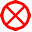
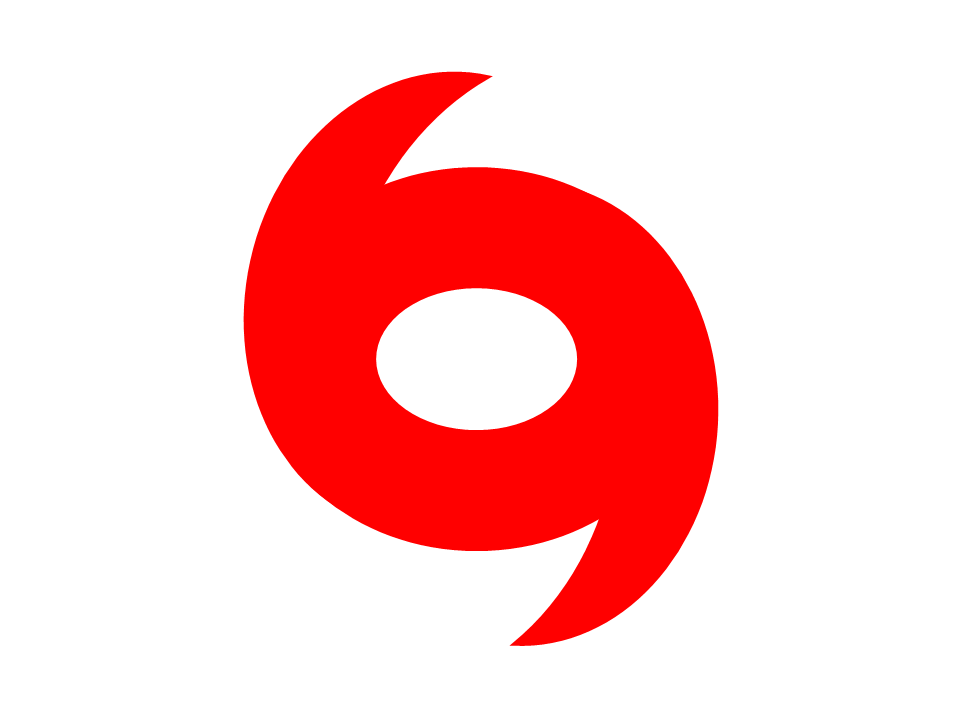
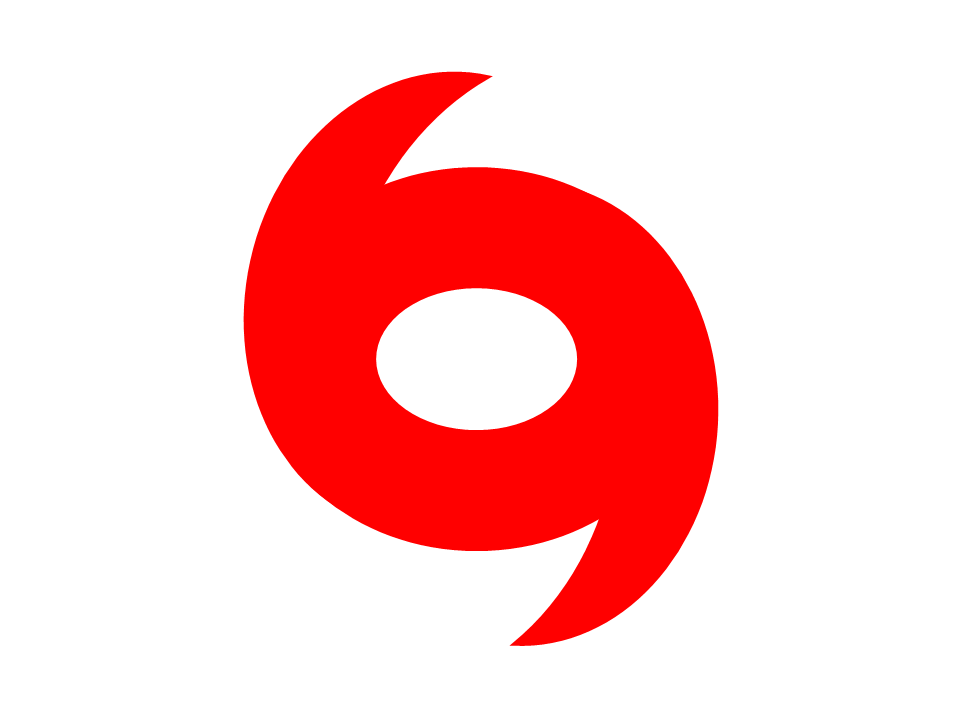
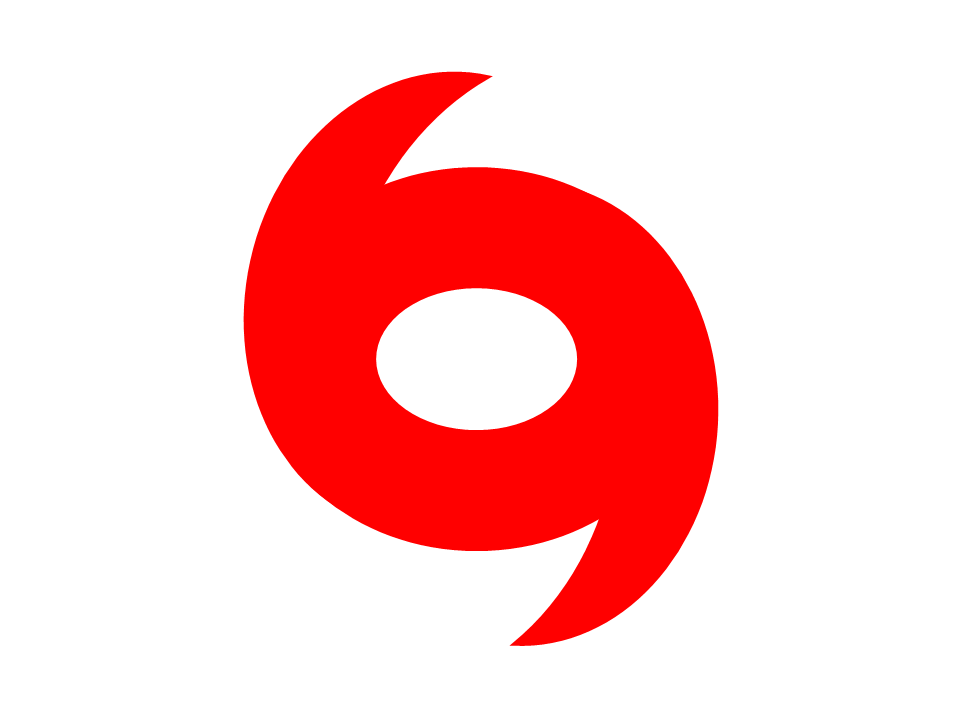
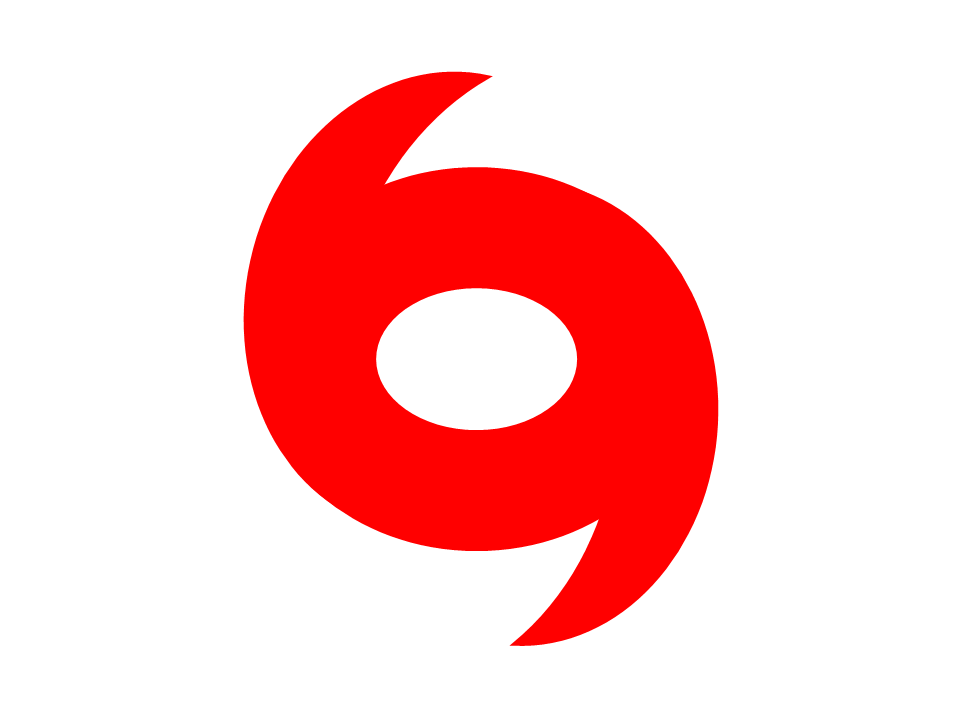
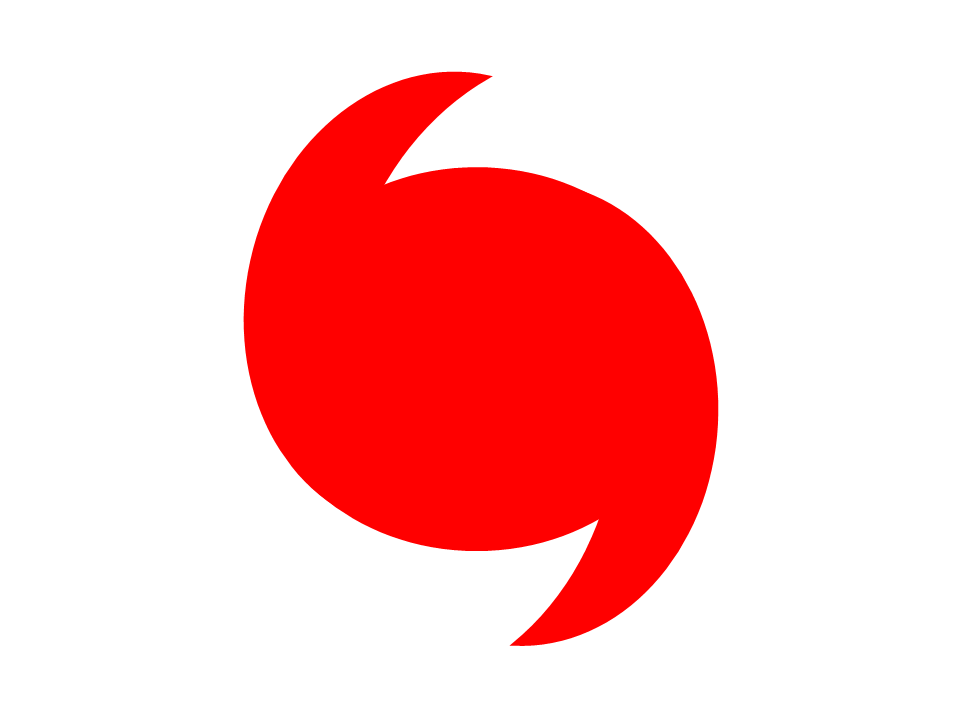
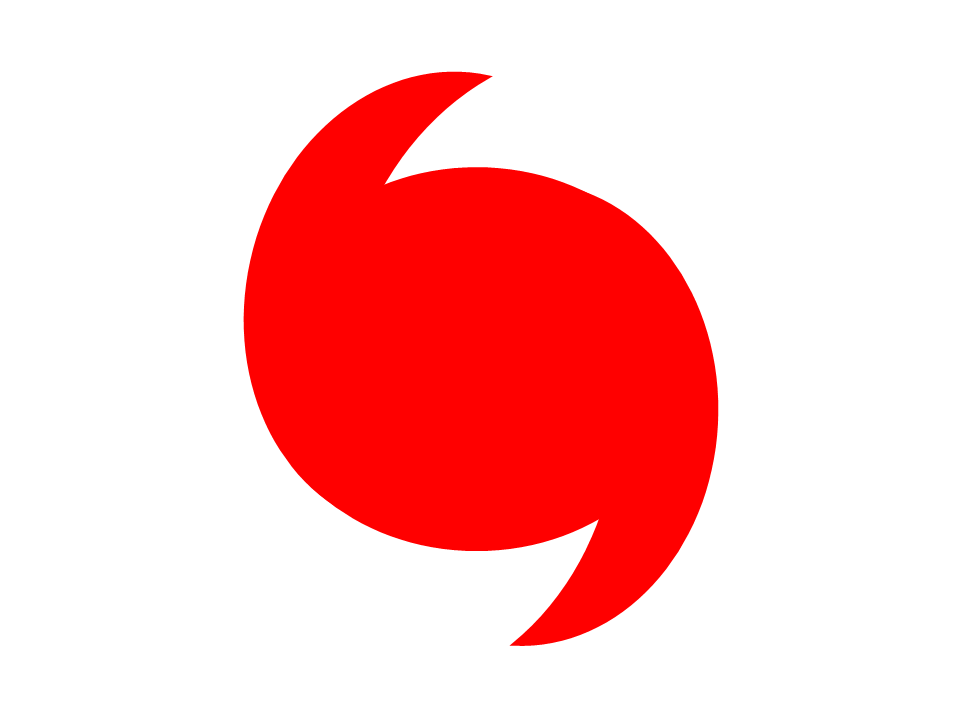
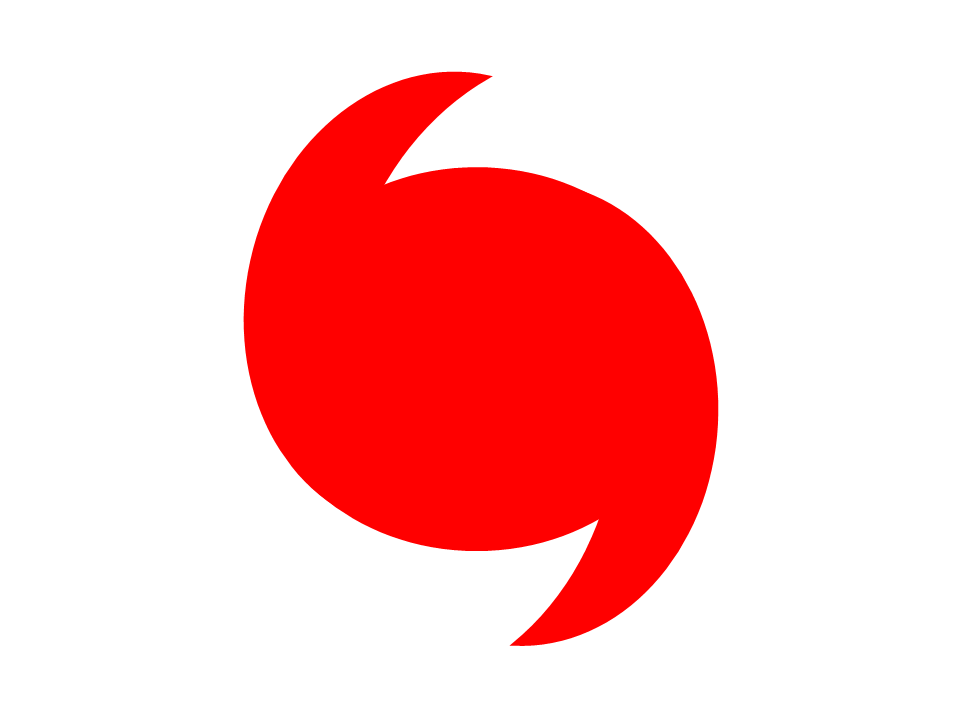
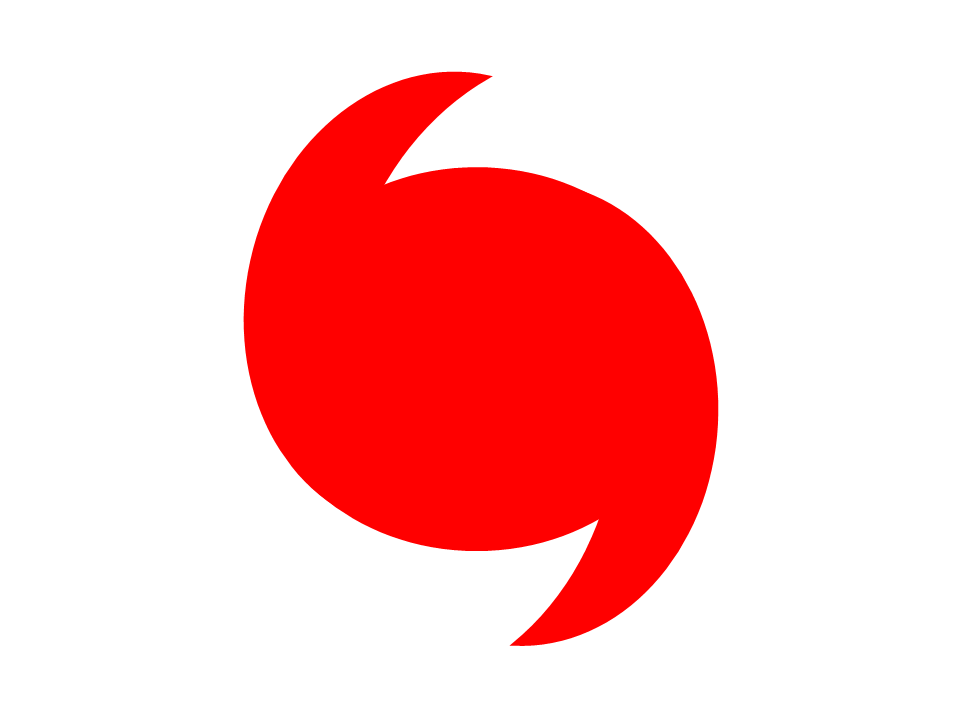
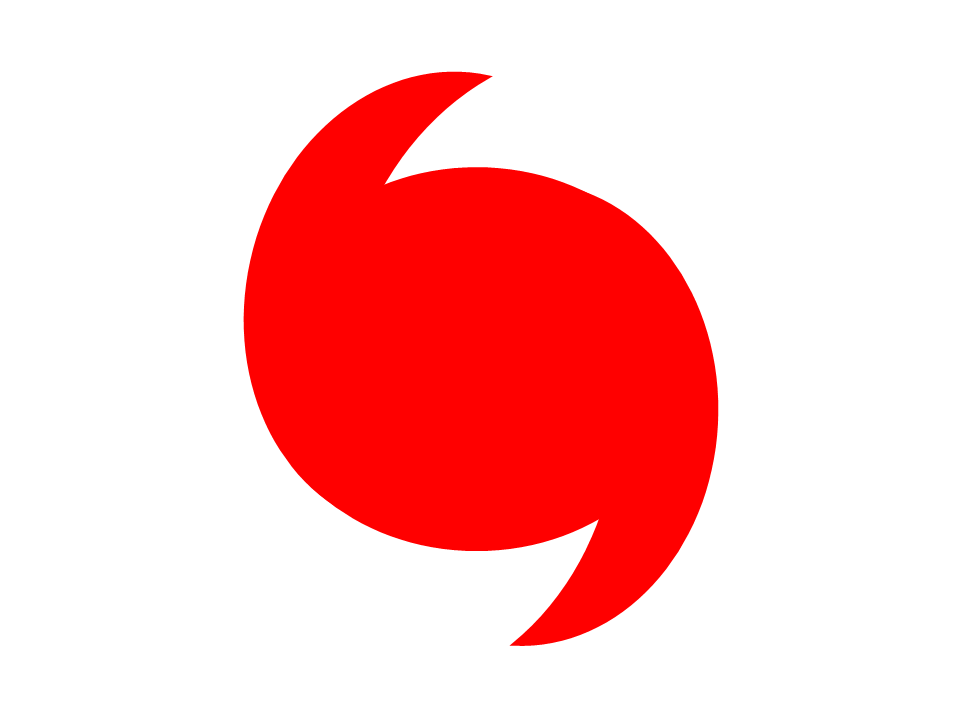
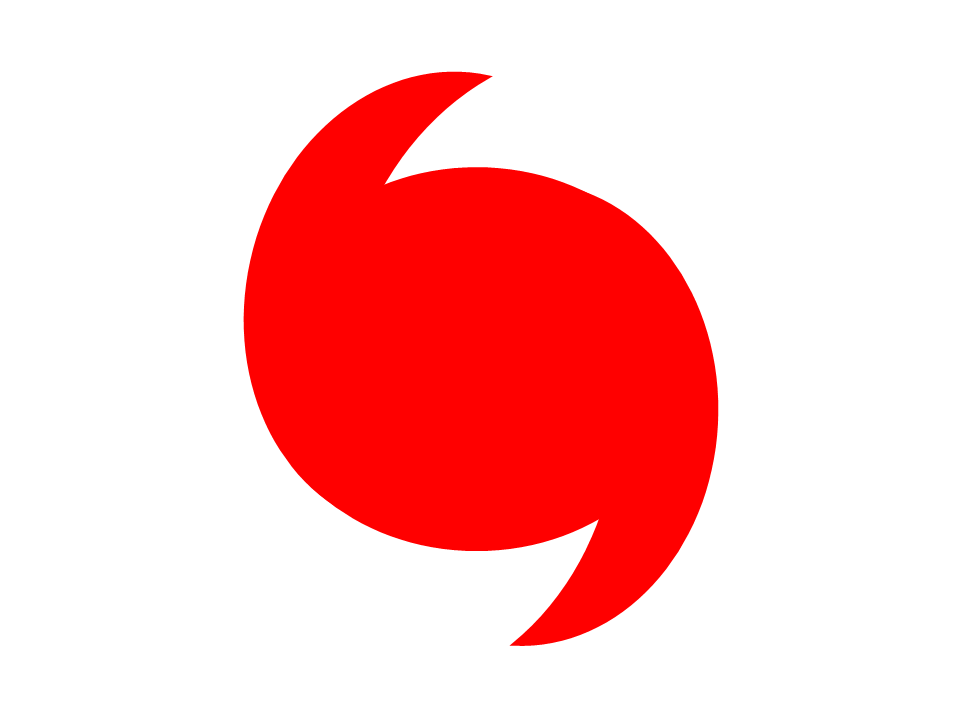
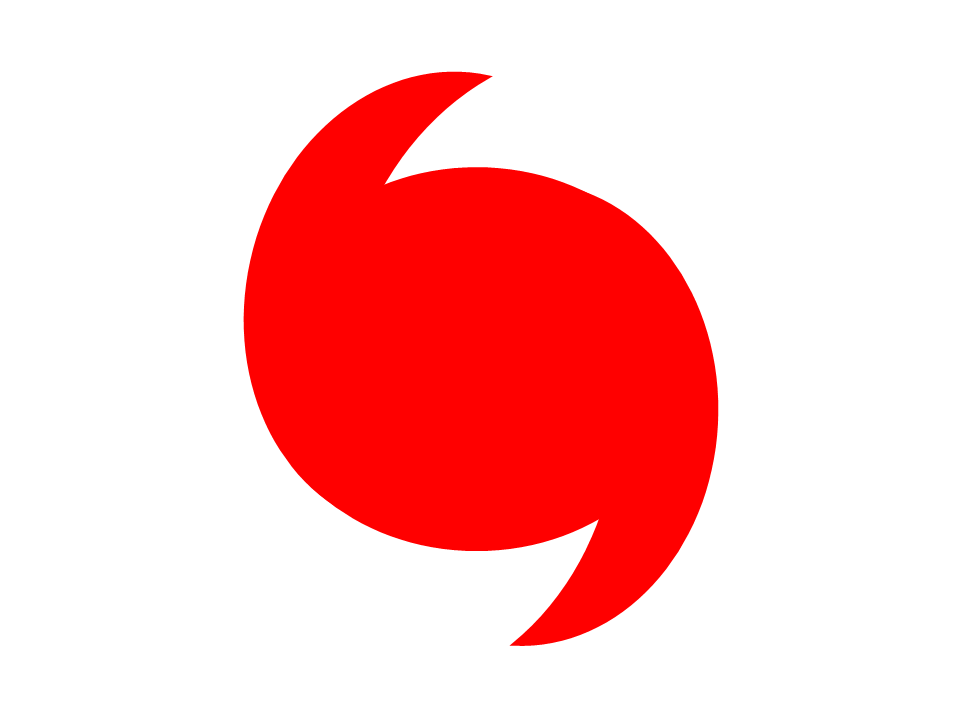
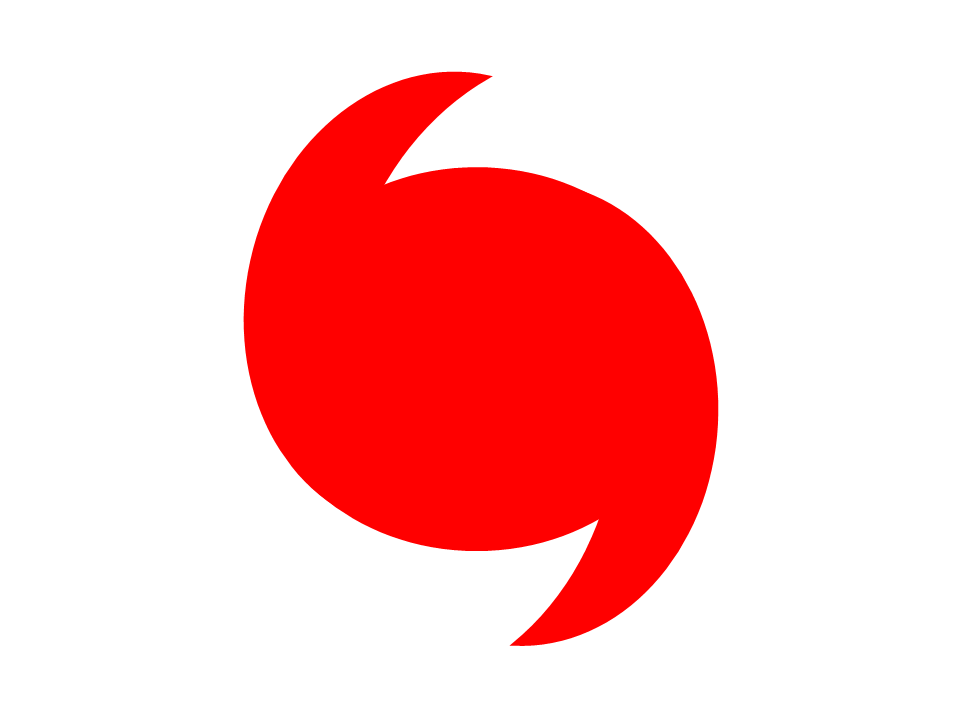
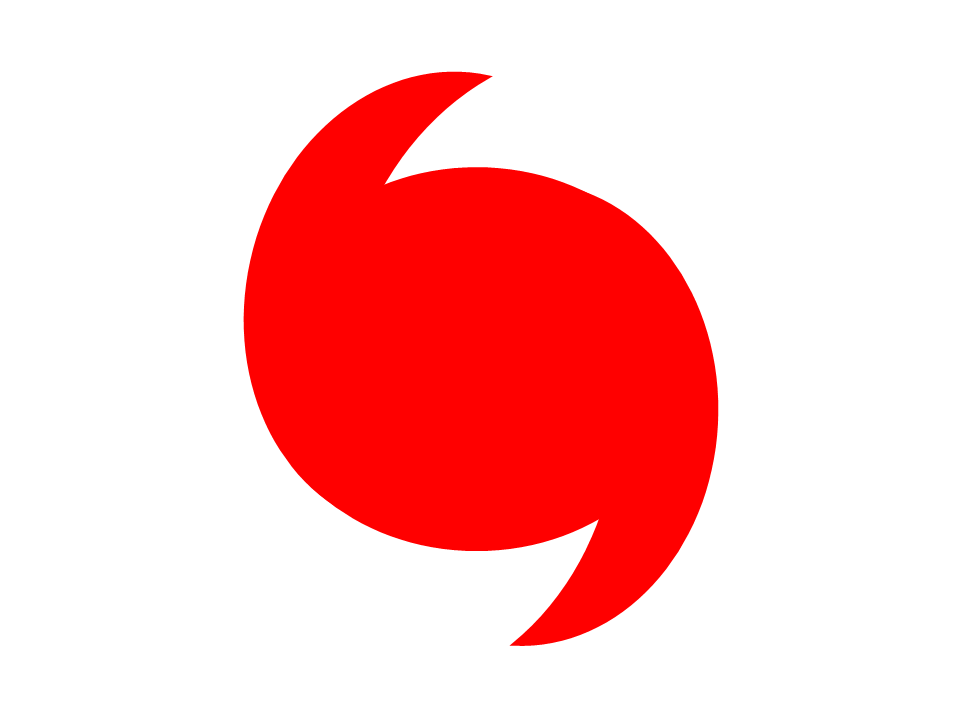
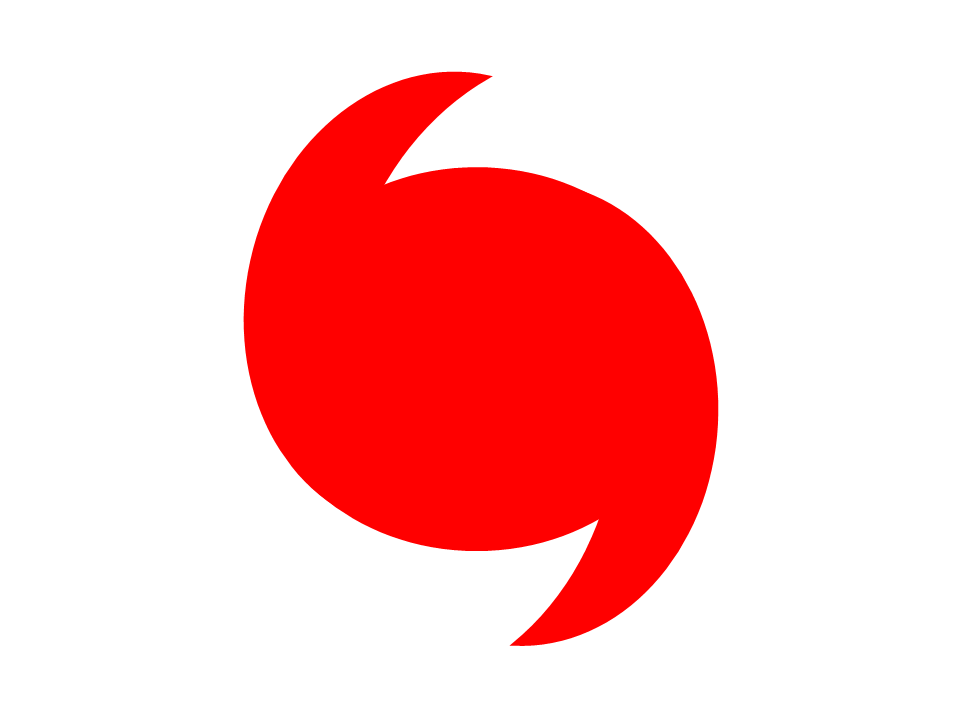
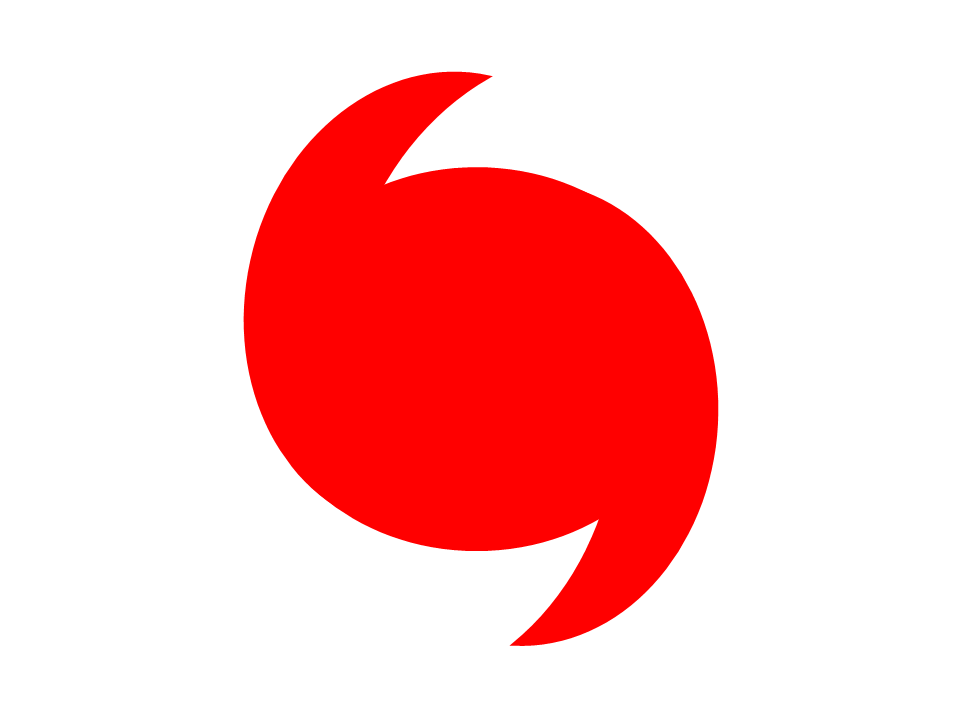
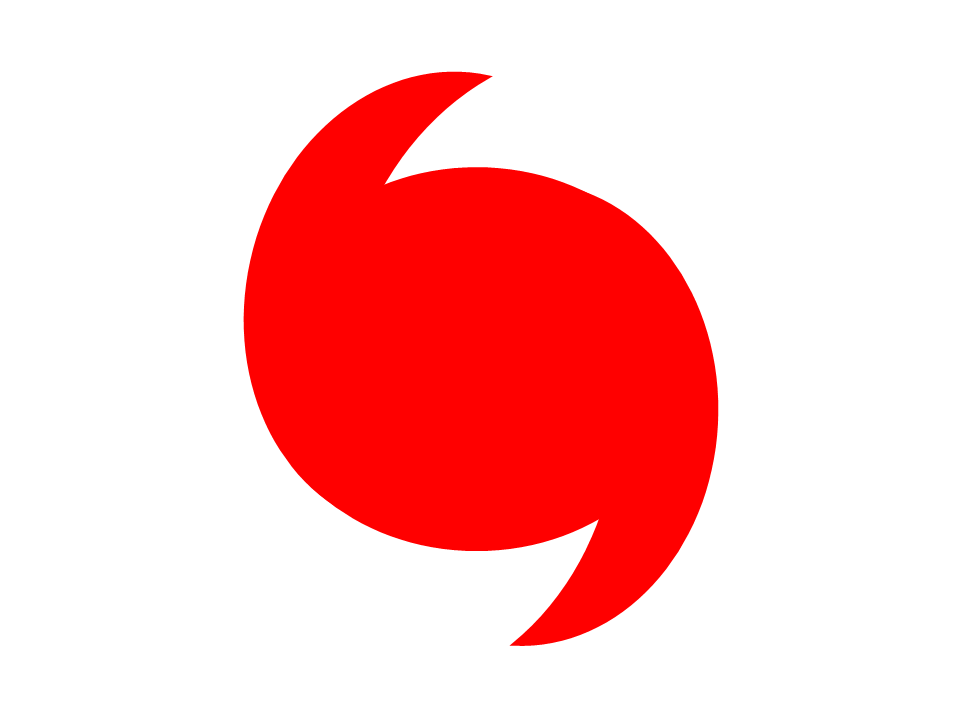
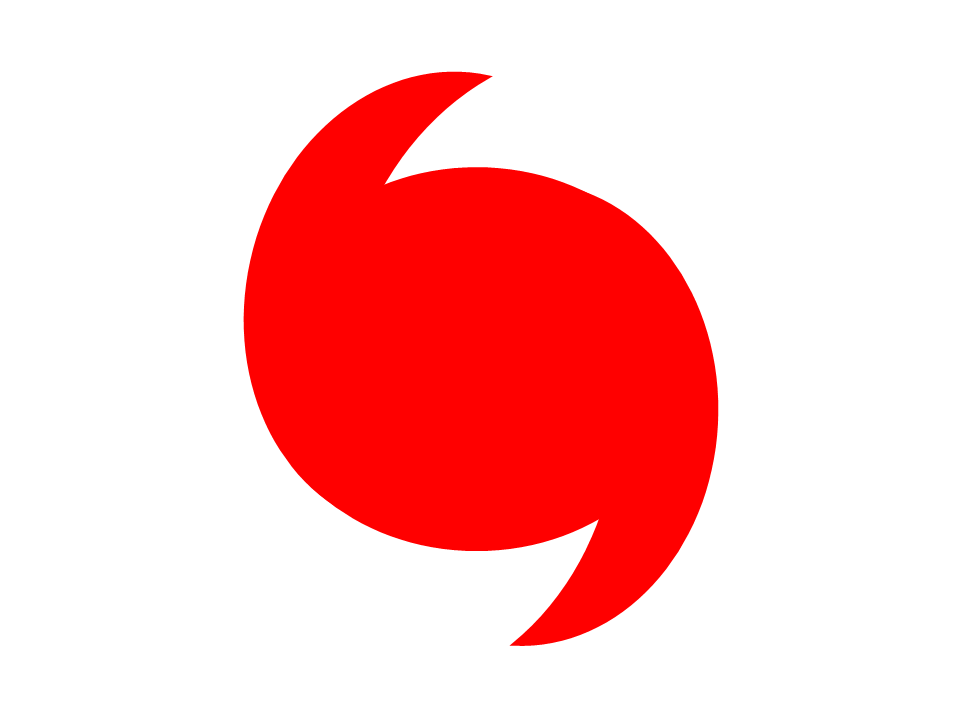
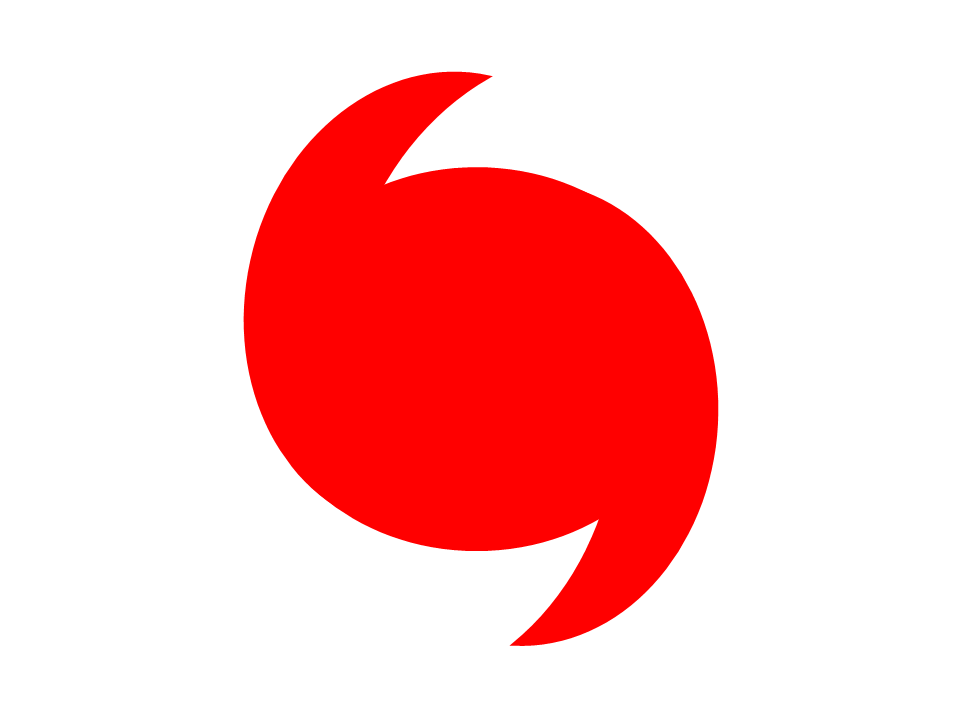
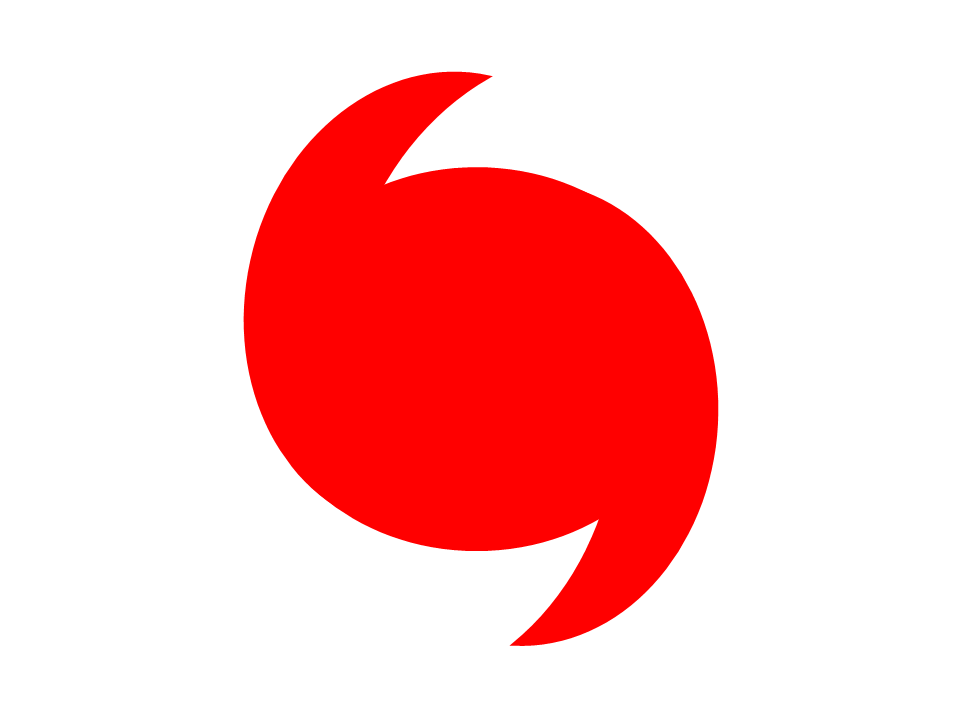
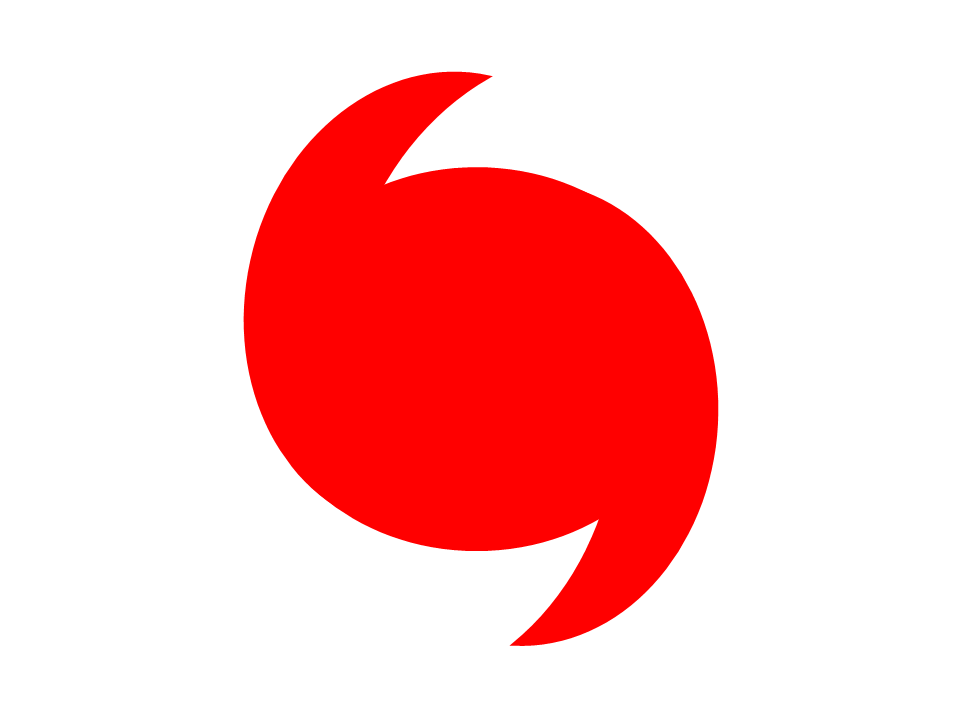

In [25]:
# 4) Vẽ cone + track + forecast trên map với icon kiểu app thời tiết

def calculate_bearing(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dlon = math.radians(lon2 - lon1)
    x = math.sin(dlon) * math.cos(phi2)
    y = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dlon)
    bearing = math.degrees(math.atan2(x, y))
    return (bearing + 360.0) % 360.0


def destination_point(lat: float, lon: float, bearing_deg: float, distance_km: float) -> tuple[float, float]:
    radius_km = 6371.0
    delta = distance_km / radius_km
    theta = math.radians(bearing_deg)
    phi1 = math.radians(lat)
    lam1 = math.radians(lon)

    sin_phi2 = math.sin(phi1) * math.cos(delta) + math.cos(phi1) * math.sin(delta) * math.cos(theta)
    phi2 = math.asin(max(-1.0, min(1.0, sin_phi2)))
    y = math.sin(theta) * math.sin(delta) * math.cos(phi1)
    x = math.cos(delta) - math.sin(phi1) * math.sin(phi2)
    lam2 = lam1 + math.atan2(y, x)
    return math.degrees(phi2), (math.degrees(lam2) + 540.0) % 360.0 - 180.0

obs_df = obs_df.copy()
obs_df["icon_file"] = obs_df.apply(
    lambda r: icon_file_from_type(str(r.get("type", "TD")), lat=float(r["lat"])),
    axis=1,
)

all_lat = pd.concat([obs_df["lat"], forecast_df["lat"]])
all_lon = pd.concat([obs_df["lon"], forecast_df["lon"]])
center_lat = float(all_lat.mean())
center_lon = float(all_lon.mean())

m_cone = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles="CartoDB positron")

folium.PolyLine(
    locations=obs_df[["lat", "lon"]].values.tolist(),
    color="#1f77b4",
    weight=4,
    opacity=0.95,
    tooltip="Observed track (2017-08-30 -> 2017-09-02 00:00)",
).add_to(m_cone)

folium.PolyLine(
    locations=forecast_df[["lat", "lon"]].values.tolist(),
    color="#d62728",
    weight=3,
    opacity=0.9,
    dash_array="8, 8",
    tooltip="Fake forecast track (+120h)",
).add_to(m_cone)

for _, row in forecast_df.iterrows():
    folium.Circle(
        location=[float(row["lat"]), float(row["lon"])],
        radius=float(row["cone_error_km"]) * 1000.0,
        color="#ff7f0e",
        fill=True,
        fill_color="#ff7f0e",
        fill_opacity=0.08,
        weight=1,
        popup=f"fhr={int(row['fhr'])}h | cone={row['cone_error_km']} km",
    ).add_to(m_cone)

left_edge = []
right_edge = []
for i in range(len(forecast_df)):
    lat_i = float(forecast_df.iloc[i]["lat"])
    lon_i = float(forecast_df.iloc[i]["lon"])
    err_km = float(forecast_df.iloc[i]["cone_error_km"])
    if i < len(forecast_df) - 1:
        lat_n = float(forecast_df.iloc[i + 1]["lat"])
        lon_n = float(forecast_df.iloc[i + 1]["lon"])
        heading = calculate_bearing(lat_i, lon_i, lat_n, lon_n)
    elif i > 0:
        lat_p = float(forecast_df.iloc[i - 1]["lat"])
        lon_p = float(forecast_df.iloc[i - 1]["lon"])
        heading = calculate_bearing(lat_p, lon_p, lat_i, lon_i)
    else:
        heading = 0.0
    left_pt = destination_point(lat_i, lon_i, heading - 90.0, err_km)
    right_pt = destination_point(lat_i, lon_i, heading + 90.0, err_km)
    left_edge.append([left_pt[0], left_pt[1]])
    right_edge.append([right_pt[0], right_pt[1]])

cone_polygon = left_edge + right_edge[::-1]
folium.Polygon(
    locations=cone_polygon,
    color="#ff7f0e",
    fill=True,
    fill_color="#ffbb78",
    fill_opacity=0.18,
    weight=2,
    tooltip="Approximate forecast cone",
).add_to(m_cone)

for _, row in obs_df.iterrows():
    icon_path = image_dir / row["icon_file"]
    icon = folium.CustomIcon(icon_image=str(icon_path), icon_size=(22, 22), icon_anchor=(11, 11))
    folium.Marker(
        location=[float(row["lat"]), float(row["lon"])],
        icon=icon,
        popup=(
            f"Observed: {row['time']}<br>"
            f"Type: {row.get('type', 'NA')}<br>"
            f"Wind: {row.get('vmax', 'NA')} kt<br>"
            f"Pressure: {row.get('mslp', 'NA')} mb"
        ),
    ).add_to(m_cone)

for _, row in forecast_df.iterrows():
    icon_path = image_dir / row["icon_file"]
    icon = folium.CustomIcon(icon_image=str(icon_path), icon_size=(24, 24), icon_anchor=(12, 12))
    folium.Marker(
        location=[float(row["lat"]), float(row["lon"])],
        icon=icon,
        popup=(
            f"Forecast time: {row['time']}<br>"
            f"fhr: {int(row['fhr'])}h<br>"
            f"Type (fake): {row['type']}<br>"
            f"Vmax (interp): {round(float(row['vmax']), 1)} kt<br>"
            f"Cone error: {row['cone_error_km']} km"
        ),
    ).add_to(m_cone)

legend_items = []
for stem, meta in ICON_DEFINITIONS.items():
    legend_items.append(
        f"<div style='display:flex;align-items:center;gap:8px;margin-bottom:4px;'>"
        f"<img src='images/{meta['file']}' width='16' height='16'/>"
        f"<span>{stem} - {meta['label']}</span></div>"
    )
legend_html_dynamic = "".join(legend_items)

legend = f"""
<div style="
    position: fixed; 
    bottom: 18px; left: 18px; width: 320px; max-height: 260px; overflow-y: auto; z-index: 9999;
    background: rgba(255,255,255,0.96); border: 1px solid #999; border-radius: 10px;
    padding: 10px; font-size: 12px; box-shadow: 2px 2px 8px rgba(0,0,0,0.25);
">
  <b>Clime-style Storm Layer (Irma Demo)</b><br>
  <div style='margin:6px 0;'>
    <span style="color:#1f77b4;">&#9632;</span> Observed track
    <span style='margin-left:10px;color:#d62728;'>&#9632;</span> Forecast track
    <span style='margin-left:10px;color:#ff7f0e;'>&#9632;</span> Cone
  </div>
  {legend_html_dynamic}
</div>
"""
m_cone.get_root().html.add_child(folium.Element(legend))

cone_html = "irma_2017_cone_fake_forecast_map.html"
m_cone.save(cone_html)
print(f"Da tao map cone demo: {cone_html}")
m_cone

In [1]:
from tropycal import realtime
import pandas as pd

# 1. Khởi tạo đối tượng Realtime
# Lưu ý: jtwc_source='ucar' là lựa chọn tốt nhất hiện nay
rtc = realtime.Realtime(jtwc=True, jtwc_source='ucar')

# 2. Lấy danh sách các cơn bão (all_storms lúc này là một LIST)
all_storms = rtc.storms

# 3. Trích xuất thông tin
storm_list = []
for storm_obj in all_storms:
    # Lọc chỉ lấy các cơn bão bắt đầu trong năm 2026
    if storm_obj.date[0].year == 2026:
        storm_list.append({
            'id': storm_obj.id,        # ID như WP112026
            'name': storm_obj.name,    # Tên bão (hoặc INVEST nếu chưa đặt tên)
            'basin': storm_obj.basin,  # Khu vực (vđ: west_pacific)
            'start_date': storm_obj.date[0],
            'max_wind': storm_obj.vmax.max() if len(storm_obj.vmax) > 0 else 0
        })

# 4. Chuyển sang DataFrame
df = pd.DataFrame(storm_list)

if not df.empty:
    # Sắp xếp theo ngày mới nhất và lấy top 10
    df_sorted = df.sort_values(by='start_date', ascending=False)
    top_10_recent = df_sorted.head(10)

    print(f"--- Tìm thấy {len(df)} cơn bão trong năm 2026 ---")
    print(top_10_recent[['id', 'name', 'basin', 'start_date', 'max_wind']])
else:
    print("Hiện chưa có dữ liệu bão cho năm 2026 trong nguồn này.")

d:\miniconda3\envs\forgery_env\lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


--> Starting to read in current storm data
--> Completed reading in current storm data (51.6 seconds)
Hiện chưa có dữ liệu bão cho năm 2026 trong nguồn này.


In [2]:
from tropycal import tracks
import pandas as pd
from datetime import datetime

# 1. Khởi tạo Dataset từ nguồn IBTrACS (Toàn cầu bao gồm JTWC)
# Lưu ý: Lần đầu chạy sẽ mất vài phút để tải file dữ liệu về máy.
dset = tracks.TrackDataset(basin='all', source='ibtracs')

# 2. Lấy danh sách ID bão của năm 2026
# Chúng ta lấy tất cả các khu vực (wp, sh, io, al, ep)
storm_ids = dset.get_storm_ids(year=2026)

storm_list = []

# 3. Duyệt qua từng ID bão để lấy thông tin
for s_id in storm_ids:
    storm_obj = dset.get_storm(s_id)
    storm_list.append({
        'id': s_id,
        'name': storm_obj.name,
        'basin': storm_obj.basin,
        'start_date': storm_obj.date[0],
        'vmax_max': storm_obj.vmax.max() if len(storm_obj.vmax) > 0 else 0,
        'obj': storm_obj # Lưu đối tượng để vẽ biểu đồ sau này
    })

# 4. Sắp xếp và lấy 10 cơn bão mới nhất
df = pd.DataFrame(storm_list)
if not df.empty:
    df_sorted = df.sort_values(by='start_date', ascending=False).head(10)
    
    print(f"--- Top 10 cơn bão năm 2026 ---")
    print(df_sorted[['id', 'name', 'basin', 'start_date', 'vmax_max']])
    
    # 5. Ví dụ: Lấy dữ liệu Track của cơn bão mới nhất để hiển thị
    latest_storm = df_sorted.iloc[0]['obj']
    track_data = latest_storm.to_dataframe()
    print("\n--- Dữ liệu Track của cơn bão gần nhất ---")
    print(track_data[['date', 'lat', 'lon', 'vmax']].tail())
    
    # Vẽ biểu đồ nếu cần (Yêu cầu cài đặt cartopy)
    # latest_storm.plot() 
else:
    print("Vẫn không tìm thấy dữ liệu. Có thể IBTrACS chưa kịp cập nhật bản ghi năm 2026.")

--> Starting to read in ibtracs data
--> Completed reading in ibtracs data (310.81 seconds)


AttributeError: 'TrackDataset' object has no attribute 'get_storm_ids'

In [ ]:
from tropycal import tracks
import pandas as pd

# 1. Khoi tao Dataset tu nguon IBTrACS (toan cau bao gom JTWC)
# Luu y: Lan dau chay se mat vai phut de tai file du lieu ve may.
dset = tracks.TrackDataset(basin='all', source='ibtracs')

# 2. Thu thap danh sach storm id mot cach tuong thich nhieu phien ban tropycal
storm_ids: list[str] = []

# Cach 1: Lay tu dset.data (pho bien trong TrackDataset)
dataset_data = getattr(dset, 'data', None)
if isinstance(dataset_data, dict):
    storm_ids = list(dataset_data.keys())

# Cach 2 (fallback): Lay tu object season neu co
if not storm_ids and hasattr(dset, 'get_season'):
    try:
        season = dset.get_season(2026)

        season_storms = getattr(season, 'storms', None)
        if isinstance(season_storms, dict):
            storm_ids = list(season_storms.keys())

        if not storm_ids:
            season_dict = getattr(season, 'dict', None)
            if isinstance(season_dict, dict):
                storm_ids = [k for k, v in season_dict.items() if isinstance(v, dict)]
    except Exception as exc:
        print(f"Khong the lay season 2026 tu fallback: {exc}")

storm_ids = sorted(set(storm_ids))
storm_list = []

# 3. Duyet qua tung storm id, loc dung nam 2026
for s_id in storm_ids:
    try:
        storm_obj = dset.get_storm(s_id)
    except Exception:
        continue

    dates = getattr(storm_obj, 'date', [])
    if len(dates) == 0 or dates[0].year != 2026:
        continue

    vmax_series = getattr(storm_obj, 'vmax', [])
    vmax_max = vmax_series.max() if hasattr(vmax_series, 'max') and len(vmax_series) > 0 else 0

    storm_list.append({
        'id': s_id,
        'name': getattr(storm_obj, 'name', 'UNKNOWN'),
        'basin': getattr(storm_obj, 'basin', 'UNKNOWN'),
        'start_date': dates[0],
        'vmax_max': vmax_max,
        'obj': storm_obj,  # Luu doi tuong de xem track sau nay
    })

# 4. Sap xep va in 10 con bao moi nhat
if storm_list:
    df = pd.DataFrame(storm_list).sort_values(by='start_date', ascending=False).head(10)

    print("--- Top 10 con bao nam 2026 ---")
    print(df[['id', 'name', 'basin', 'start_date', 'vmax_max']])

    # 5. Vi du: Lay du lieu track cua con bao moi nhat de hien thi
    latest_storm = df.iloc[0]['obj']
    track_data = latest_storm.to_dataframe()
    print("\n--- Du lieu track cua con bao gan nhat ---")
    print(track_data[['date', 'lat', 'lon', 'vmax']].tail())

    # Ve bieu do neu can (yeu cau cai dat cartopy)
    # latest_storm.plot()
else:
    print("Khong tim thay ban ghi bao nam 2026 trong dataset IBTrACS hien tai.")

--> Starting to read in ibtracs data
--> Completed reading in ibtracs data (190.39 seconds)


In [ ]:
import tropycal.tracks as tracks
import datetime

# 1. Tải dữ liệu bão khu vực Tây Bắc Thái Bình Dương (WP) từ IBTrACS
# Lưu ý: Lần đầu chạy sẽ hơi chậm vì nó tải dữ liệu lịch sử về máy
print("Đang tải dữ liệu bão từ IBTrACS... Vui lòng đợi.")
ibtracs = tracks.TrackDataset(basin='west_pacific', source='ibtracs')

# 2. Lấy danh sách tất cả các ID bão trong khu vực WP
all_storm_ids = ibtracs.get_storm_ids()

# 3. Lấy 3 ID cuối cùng (mới nhất)
latest_3_ids = all_storm_ids[-3:]

print("-" * 30)
print(f"3 CƠN BÃO MỚI NHẤT TRONG KHU VỰC WP:")
print("-" * 30)

# 4. Duyệt qua từng ID bão để lấy thông tin chi tiết
for storm_id in latest_3_ids:
    storm = ibtracs.get_storm(storm_id)
    
    # Lấy thông tin cơ bản
    name = storm.name
    start_time = storm.date[0].strftime('%d/%m/%Y')
    end_time = storm.date[-1].strftime('%d/%m/%Y')
    max_wind = max(storm.vmax) # Sức gió cực đại (knots)
    min_mslp = min(storm.mslp) # Áp suất thấp nhất (hPa)

    print(f"Tên bão: {name} ({storm_id})")
    print(f"  - Thời gian: {start_time} đến {end_time}")
    print(f"  - Sức gió mạnh nhất: {max_wind} knots")
    print(f"  - Áp suất thấp nhất: {min_mslp} hPa")
    print("-" * 20)

# 5. (Tùy chọn) Vẽ quỹ đạo của cơn bão mới nhất
latest_storm = ibtracs.get_storm(latest_3_ids[-1])
latest_storm.plot()

## Hướng dẫn lấy forecast thực tế
1. Với bão **đang hoạt động**: dùng `tropycal.realtime.Realtime()` rồi lấy `storm.dict['forecast']` trực tiếp.
2. Với bão **lịch sử** (như Irma 2017): thường không có forecast operational trong `tracks.TrackDataset`; cần lấy từ archive của NHC/ATCF theo từng advisory.
3. Nguồn dữ liệu phổ biến:
   - NHC GIS / cone + forecast shapefile archive
   - NHC advisory text archive (public advisory / forecast advisory)
   - ATCF a-deck (forecast models) và b-deck (best track)
4. Quy trình khuyến nghị:
   - Thu thập advisory tại từng thời điểm phát hành
   - Parse các điểm forecast (fhr, lat, lon)
   - Chuẩn hóa về schema: `{'fhr':[...], 'lat':[...], 'lon':[...]}`
   - Lưu metadata: issue_time, source, agency, model
5. Khi dùng cho production, nên version hóa forecast theo `issue_time` để replay đúng trạng thái thời gian thực.